   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

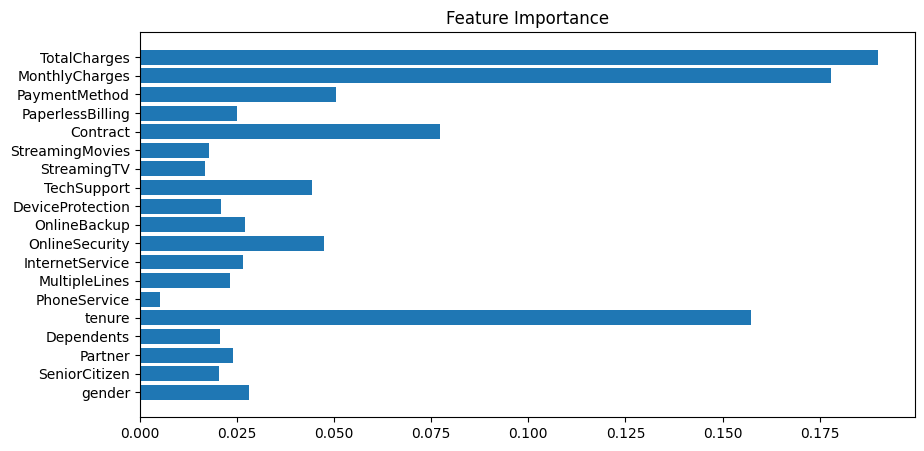

In [10]:
#Customer Churn Prediction
1. #Important Libaraies
# ===============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# ===============================
# 2. Load Dataset
# ===============================
df = pd.read_csv('/content/Telco-Customer-Churn.csv')

# Show data
print(df.head())

# ===============================
# 3. Data Cleaning
# ===============================

# Remove customerID (not useful)
df.drop('customerID', axis=1, inplace=True)

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# ===============================
# 4. Encode Categorical Data
# ===============================
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# ===============================
# 5. Split Data
# ===============================
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 6. Feature Scaling
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# 7. Train Model
# ===============================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ===============================
# 8. Predictions
# ===============================
y_pred = model.predict(X_test)

# ===============================
# 9. Evaluation
# ===============================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred))

# ===============================
# 10. Feature Importance
# ===============================
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [11]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

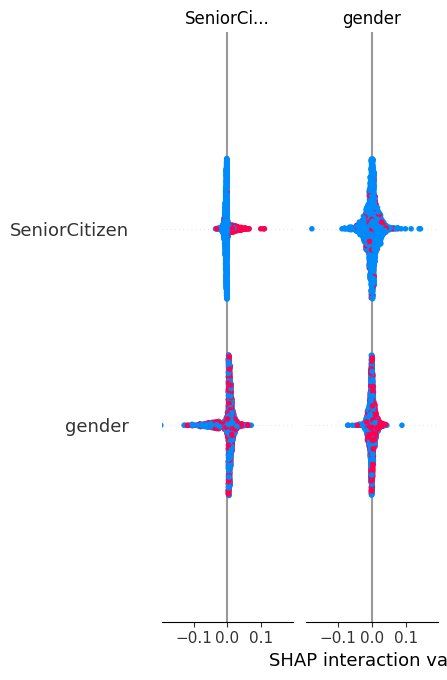

In [12]:
# Install SHAP (run once)
# ===============================
!pip install shap

# ===============================
# Import SHAP
# ===============================
import shap

# ===============================
# Create Explainer
# ===============================
explainer = shap.TreeExplainer(model)

# ===============================
# Calculate SHAP values
# ===============================
shap_values = explainer.shap_values(X_test)

# ===============================
# 1. Summary Plot (Most Important)
# ===============================
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

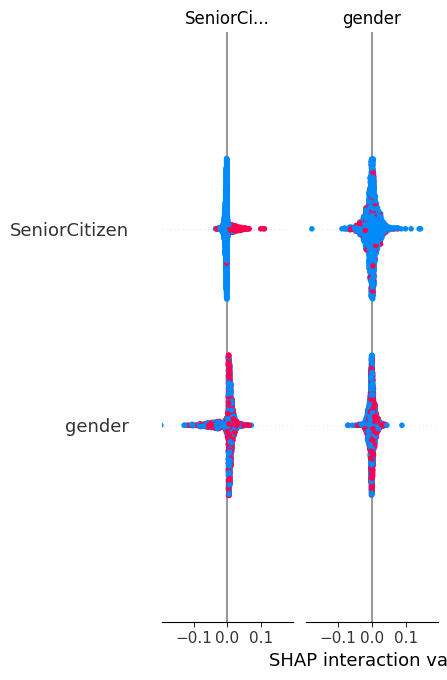

In [13]:
shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=X.columns)

In [15]:
# Save SHAP summary plot
shap.summary_plot(shap_values, X_test, show=False)
import matplotlib.pyplot as plt
plt.savefig("shap_summary.png", bbox_inches='tight')
plt.close()

# Save Feature Importance plot
plt.figure(figsize=(10,5))
plt.barh(X.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.savefig("feature_importance.png", bbox_inches='tight')
plt.close()